# Phase 3 -- Prediction engine

Lab experiment covering `nticipate/trie.py`, `nticipate/predictor.py`,
and `nticipate/userprofile.py`: the unified prediction API, latency,
accuracy (hit@k), keystroke savings, and the personalization layer.

Runs against the sample corpus by default -- swap `CORPUS_SOURCE =
"nltk"` for the real submission numbers.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import time
import random
import matplotlib.pyplot as plt
import numpy as np

from nticipate.config import load_config, resolve_path
from nticipate.preprocess import preprocess_corpus, train_dev_test_split, pad_sentence
from nticipate.ngram import build_ngram_hierarchy
from nticipate.trie import Trie
from nticipate.predictor import Predictor
from nticipate.userprofile import UserProfile

CFG = load_config()
CORPUS_SOURCE = "sample"   # "sample" (ships in repo) or "nltk" (after setup_env.py)

## 1. Build the base predictor

In [2]:
if CORPUS_SOURCE == "sample":
    with open(resolve_path("data/raw/sample_english.txt"), encoding="utf-8") as f:
        raw_text = f.read()
    raw_documents = [p for p in raw_text.split("\n\n") if p.strip()]
else:
    import nltk
    raw_documents = []
    for corpus_name in CFG["preprocessing"]["corpora_english"]:
        corpus = getattr(nltk.corpus, corpus_name)
        for fileid in corpus.fileids():
            raw_documents.append(corpus.raw(fileid))

unk_applied, vocab, truecase_map = preprocess_corpus(raw_documents)
train_sents, dev_sents, test_sents = train_dev_test_split(unk_applied)

models = build_ngram_hierarchy(train_sents, orders=[1, 2, 3], smoothing="stupid_backoff", vocab=vocab)
trie = Trie.from_vocab(vocab)
predictor = Predictor(ngram_model=models[3], trie=trie, truecase_map=truecase_map)

print(f"Vocab size:  {len(vocab)}")
print(f"Trie built, sample lookup 'th' ->", trie.words_with_prefix("th")[:5])
print(f"Sample prediction after ('<s>', 'the'):", predictor.predict(context=("<s>", "the")))

Vocab size:  71
Trie built, sample lookup 'th' -> ['the', 'their', 'they']
Sample prediction after ('<s>', 'the'): ['cat', 'castle', 'bug', 'train', 'essay']


## 2. Latency benchmark

Target: p95 under ~20ms per keystroke (see config.yaml's
`app.debounce_ms`). At this sample-corpus scale it should be trivially
fast -- the real test is on the full NLTK-corpus-scale model after
pruning (Phase 2), which is what actually ships.

In [3]:
def sample_contexts(sentences, n_samples=200, order=3, rng=None):
    rng = rng or random.Random(CFG["project"]["seed"])
    contexts = []
    for sentence in sentences:
        padded = pad_sentence(sentence, order)
        for i in range(order - 1, len(padded)):
            contexts.append(tuple(padded[i - order + 1 : i]))
    if not contexts:
        return []
    return [rng.choice(contexts) for _ in range(n_samples)]

bench_contexts = sample_contexts(dev_sents if dev_sents else train_sents, n_samples=300)

latencies_ms = []
for ctx in bench_contexts:
    start = time.perf_counter()
    predictor.predict(context=ctx, prefix="")
    latencies_ms.append((time.perf_counter() - start) * 1000)

latencies_ms = np.array(latencies_ms)
p50 = np.percentile(latencies_ms, 50)
p95 = np.percentile(latencies_ms, 95)
p99 = np.percentile(latencies_ms, 99)

print(f"p50 latency: {p50:.3f} ms")
print(f"p95 latency: {p95:.3f} ms")
print(f"p99 latency: {p99:.3f} ms")
print(f"Target (config.yaml app.debounce_ms): {CFG['app']['debounce_ms']} ms")

p50 latency: 0.232 ms
p95 latency: 0.263 ms
p99 latency: 0.283 ms
Target (config.yaml app.debounce_ms): 50 ms


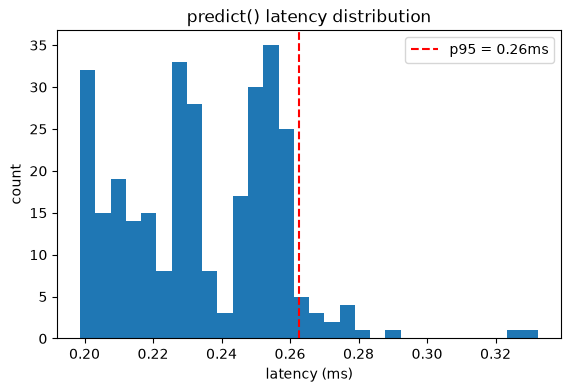

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(latencies_ms, bins=30)
ax.axvline(p95, color="red", linestyle="--", label=f"p95 = {p95:.2f}ms")
ax.set_xlabel("latency (ms)")
ax.set_ylabel("count")
ax.set_title("predict() latency distribution")
ax.legend()
plt.show()

## 3. Accuracy: hit@k

For each actual next word in the dev set, check whether it appears in
the top-k next-word predictions.

In [5]:
def evaluate_hit_at_k(predictor, sentences, ks=(1, 3, 5), order=3):
    hits = {k: 0 for k in ks}
    total = 0
    max_k = max(ks)
    for sentence in sentences:
        padded = pad_sentence(sentence, order)
        for i in range(order - 1, len(padded) - 1):  # skip predicting </s> itself as "next word"
            context = tuple(padded[i - order + 1 : i])
            actual_next = padded[i]
            predictions = predictor.predict(context=context, prefix="", k=max_k)
            total += 1
            for k in ks:
                if actual_next in predictions[:k]:
                    hits[k] += 1
    return {k: hits[k] / total if total else 0.0 for k in ks}, total

hit_rates, n_evaluated = evaluate_hit_at_k(predictor, dev_sents if dev_sents else train_sents)
print(f"Evaluated over {n_evaluated} (context, actual_next_word) pairs")
for k, rate in hit_rates.items():
    print(f"hit@{k}: {rate:.3f}")

Evaluated over 54 (context, actual_next_word) pairs


hit@1: 0.204
hit@3: 0.315
hit@5: 0.352


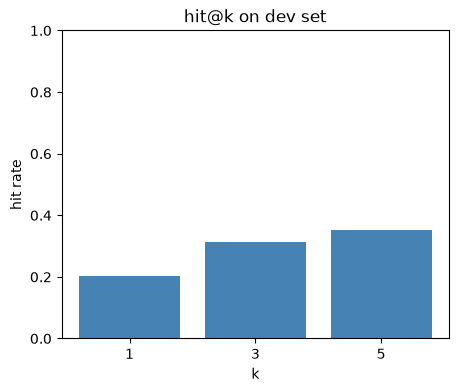

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
ks = list(hit_rates.keys())
rates = list(hit_rates.values())
ax.bar([str(k) for k in ks], rates, color="steelblue")
ax.set_xlabel("k")
ax.set_ylabel("hit rate")
ax.set_title("hit@k on dev set")
ax.set_ylim(0, 1)
plt.show()

## 4. Keystroke savings ratio

The headline product number. For each word, simulate typing it
character by character; as soon as the word appears in the top-k
completions for the prefix typed so far, count it as "accepted" (the
remaining characters + 1 Tab keystroke are saved).

In [7]:
def keystroke_savings(predictor, sentences, k=5, order=3):
    baseline_keystrokes = 0
    actual_keystrokes = 0
    words_evaluated = 0

    for sentence in sentences:
        padded = pad_sentence(sentence, order)
        # walk real words only (skip <s>/</s>)
        for i in range(order - 1, len(padded) - 1):
            word = padded[i]
            if len(word) <= 1:
                continue  # nothing to save on a 1-character "word" (e.g. punctuation)
            context = tuple(padded[i - order + 1 : i])
            baseline_keystrokes += len(word)
            words_evaluated += 1

            accepted_at = None
            for chars_typed in range(1, len(word) + 1):
                prefix = word[:chars_typed]
                predictions = predictor.predict(context=context, prefix=prefix, k=k)
                if word in predictions:
                    accepted_at = chars_typed
                    break

            if accepted_at is not None:
                actual_keystrokes += accepted_at + 1  # +1 for the Tab/accept keystroke
            else:
                actual_keystrokes += len(word)  # typed the whole thing, no acceptance

    savings_ratio = 1 - (actual_keystrokes / baseline_keystrokes) if baseline_keystrokes else 0.0
    return savings_ratio, words_evaluated, baseline_keystrokes, actual_keystrokes

ratio, n_words, baseline, actual = keystroke_savings(predictor, dev_sents if dev_sents else train_sents)
print(f"Words evaluated:      {n_words}")
print(f"Baseline keystrokes:  {baseline}")
print(f"Actual keystrokes:    {actual}")
print(f"Keystroke savings:    {ratio:.1%}")

Words evaluated:      47
Baseline keystrokes:  207
Actual keystrokes:    166
Keystroke savings:    19.8%


## 5. Personalization in action

Before/after comparison: predictions for a context involving a word
the base corpus has never seen, before and after the user model has
"learned" it.

In [8]:
novel_word = "quantum"  # not in the sample corpus at all
context = ("<s>", "the")

before = predictor.predict(context=context, prefix="qu")
print("Before learning, prefix 'qu' ->", before)

profile = UserProfile()
for _ in range(300):
    profile.observe_sentence(["the", novel_word, "computer", "was", "fast"])

personalized_predictor = Predictor(
    ngram_model=models[3], trie=trie, user_profile=profile, truecase_map=truecase_map
)
after = personalized_predictor.predict(context=context, prefix="qu")
print("After learning (300 tokens, lambda =", round(profile.current_lambda(), 3), "), prefix 'qu' ->", after)

after_next_word = personalized_predictor.predict(context=context, prefix="")
print("Next-word predictions after learning:", after_next_word)

Before learning, prefix 'qu' -> ['quickly']
After learning (300 tokens, lambda = 0.303 ), prefix 'qu' -> ['quantum', 'quickly']
Next-word predictions after learning: ['quantum', 'cat', 'castle', 'bug', 'train']


## Summary table (paste into report)

| Metric | Value |
|---|---|
| p50 / p95 / p99 latency (ms) | see section 2 |
| hit@1 / hit@3 / hit@5 | see section 3 |
| Keystroke savings ratio | see section 4 |

Re-run with `CORPUS_SOURCE = "nltk"` for the real submission numbers.
Expect hit@k to rise and keystroke savings to improve noticeably with
the full corpus -- this sample corpus is too small and repetitive for
the n-gram model to have learned much beyond a handful of fixed
phrases, which caps how well it can generalize to genuinely novel dev
sentences.